# Trustworthy Vision Transformer-Based Framework for Industrial Surface Defect Detection

### M.Tech Dissertation

**Student:** Priyam Banerjee

**Backbone:** Swin Transformer

**Dataset:** NEU Surface Defect Database

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected.")

Device: cuda
GPU: Tesla T4


In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f"Random seed set to {SEED}")

Random seed set to 42


In [5]:
CONFIG = {
    "image_size": 224,
    "batch_size": 32,
    "epochs": 30,
    "learning_rate": 1e-4,
    "num_classes": 6
}
print(CONFIG)

{'image_size': 224, 'batch_size': 32, 'epochs': 30, 'learning_rate': 0.0001, 'num_classes': 6}


In [6]:
DATASET_PATH = "/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database"
for root, dirs, files in os.walk(DATASET_PATH):
    print(root)
    if files:
        print("  Number of files:", len(files))
    print("-" * 60)

/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database
------------------------------------------------------------
/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET
------------------------------------------------------------
/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/validation
------------------------------------------------------------
/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/validation/annotations
  Number of files: 361
------------------------------------------------------------
/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/validation/images
------------------------------------------------------------
/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/validation/images/inclusion
  Number of files: 60
------------------------------------------------------------
/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/

In [7]:
# Root directory
ROOT_DIR = "/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET"
# Training images
TRAIN_DIR = ROOT_DIR + "/train/images"
# Validation images
VAL_DIR = ROOT_DIR + "/validation/images"
print("Training Folder :", TRAIN_DIR)
print("Validation Folder:", VAL_DIR)

Training Folder : /kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/train/images
Validation Folder: /kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/validation/images


In [8]:
classes = sorted(os.listdir(TRAIN_DIR))
print("Number of Classes:", len(classes))
print("\nClass Names:")
for i, cls in enumerate(classes):
    print(f"{i}: {cls}")

Number of Classes: 6

Class Names:
0: crazing
1: inclusion
2: patches
3: pitted_surface
4: rolled-in_scale
5: scratches


In [9]:
print("Training Images Per Class")
print("-" * 35)
for cls in classes:
    class_path = os.path.join(TRAIN_DIR, cls)
    count = len(os.listdir(class_path))
    print(f"{cls:<20} {count}")

Training Images Per Class
-----------------------------------
crazing              240
inclusion            240
patches              240
pitted_surface       240
rolled-in_scale      240
scratches            240


In [10]:
# Training transformations
train_transform = transforms.Compose([
    transforms.Resize(
        (CONFIG["image_size"], CONFIG["image_size"])
    ),
    transforms.RandomHorizontalFlip(
        p=0.5
    ),
    transforms.RandomRotation(
        degrees=10
    ),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
# Validation transformations
val_transform = transforms.Compose([
    transforms.Resize(
        (CONFIG["image_size"], CONFIG["image_size"])
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
print("Transforms created successfully!")

Transforms created successfully!


In [11]:
from torchvision.datasets import ImageFolder
train_dataset = ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)
val_dataset = ImageFolder(
    root=VAL_DIR,
    transform=val_transform
)
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Training samples: 1440
Validation samples: 360


In [12]:
print(train_dataset.class_to_idx)

{'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}


In [13]:
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=2
)
val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=2
)
print("DataLoaders created!")

DataLoaders created!


In [16]:
images, labels = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label shape:", labels.shape)
print("Labels:", labels[:10])

Image batch shape: torch.Size([32, 3, 224, 224])
Label shape: torch.Size([32])
Labels: tensor([5, 5, 5, 2, 5, 4, 2, 3, 2, 1])


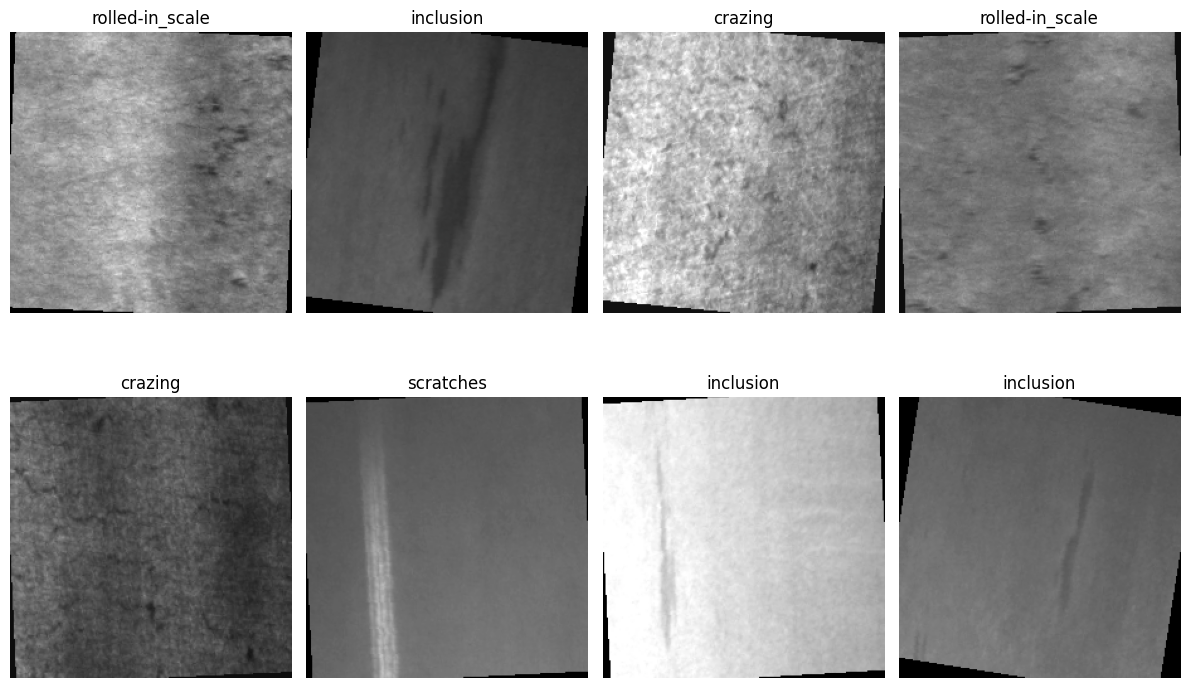

In [17]:
images, labels = next(iter(train_loader))
plt.figure(figsize=(12, 8))
for i in range(8):
    img = images[i].permute(1, 2, 0)
    # Reverse ImageNet normalization
    img = img * torch.tensor([0.229, 0.224, 0.225])
    img = img + torch.tensor([0.485, 0.456, 0.406])
    img = torch.clamp(img, 0, 1)
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(
        train_dataset.classes[labels[i]]
    )
    plt.axis("off")
plt.tight_layout()
plt.show()

In [18]:
from torchvision.models import swin_t, Swin_T_Weights
print("Swin Transformer imported successfully")

Swin Transformer imported successfully


In [19]:
weights = Swin_T_Weights.DEFAULT
model = swin_t(
    weights=weights
)
print("Pretrained Swin Transformer loaded")

Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 177MB/s]  


Pretrained Swin Transformer loaded


In [20]:
print(model.head)

Linear(in_features=768, out_features=1000, bias=True)


In [21]:
num_features = model.head.in_features
model.head = nn.Linear(
    num_features,
    CONFIG["num_classes"]
)
print(model.head)

Linear(in_features=768, out_features=6, bias=True)


In [22]:
model = model.to(device)
print("Model moved to:", device)

Model moved to: cuda


In [23]:
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)
print(
    f"Trainable parameters: {trainable_params/1e6:.2f} Million"
)

Trainable parameters: 27.52 Million


In [24]:
images, labels = next(iter(train_loader))
images = images.to(device)
outputs = model(images)
print("Output shape:", outputs.shape)

Output shape: torch.Size([32, 6])


In [25]:
criterion = nn.CrossEntropyLoss()
print("Loss function created")

Loss function created


In [26]:
optimizer = optim.AdamW(
    model.parameters(),
    lr=CONFIG["learning_rate"],
    weight_decay=1e-4
)
print("Optimizer created")

Optimizer created


In [27]:
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CONFIG["epochs"]
)
print("Scheduler created")

Scheduler created


In [28]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in tqdm(loader):
        images = images.to(device)
        labels = labels.to(device)
        # Forward pass
        outputs = model(images)
        loss = criterion(
            outputs,
            labels
        )
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(
            outputs,
            1
        )
        total += labels.size(0)
        correct += (
            predicted == labels
        ).sum().item()
    epoch_loss = running_loss / len(loader)
    epoch_accuracy = (
        correct / total
    ) * 100
    return epoch_loss, epoch_accuracy

In [29]:
def validate(
    model,
    loader,
    criterion,
    device
):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(loader):
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(
                outputs,
                labels
            )
            running_loss += loss.item()
            _, predicted = torch.max(
                outputs,
                1
            )
            total += labels.size(0)
            correct += (
                predicted == labels
            ).sum().item()
    loss = running_loss / len(loader)
    accuracy = (
        correct / total
    ) * 100
    return loss, accuracy

In [30]:
EPOCHS = CONFIG["epochs"]
best_accuracy = 0
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

In [31]:
from tqdm.auto import tqdm
print("tqdm imported successfully")

tqdm imported successfully


In [32]:
for epoch in range(EPOCHS):
    print(
        f"\nEpoch {epoch+1}/{EPOCHS}"
    )
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )
    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )
    scheduler.step()
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}%"
    )
    print(
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )
    if val_acc > best_accuracy:
        best_accuracy = val_acc
        torch.save(
            model.state_dict(),
            "/kaggle/working/best_swin_neu.pth"
        )
        print("Best model saved!")


Epoch 1/30


  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

Train Loss: 0.2495 | Train Acc: 93.06%
Val Loss: 0.0231 | Val Acc: 99.44%
Best model saved!

Epoch 2/30


  0%|          | 0/45 [00:00<?, ?it/s]

...

  0%|          | 0/12 [00:00<?, ?it/s]

Train Loss: 0.0001 | Train Acc: 100.00%
Val Loss: 0.0109 | Val Acc: 99.72%

Epoch 30/30


  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

Train Loss: 0.0002 | Train Acc: 100.00%
Val Loss: 0.0109 | Val Acc: 99.72%


In [33]:
best_model = swin_t(
    weights=None
)
best_model.head = nn.Linear(
    best_model.head.in_features,
    CONFIG["num_classes"]
)
best_model.load_state_dict(
    torch.load(
        "/kaggle/working/best_swin_neu.pth"
    )
)
best_model = best_model.to(device)
best_model.eval()
print("Best model loaded successfully")

Best model loaded successfully


In [34]:
all_predictions = []
all_labels = []
with torch.no_grad():
    for images, labels in tqdm(val_loader):
        images = images.to(device)
        outputs = best_model(images)
        predictions = torch.argmax(
            outputs,
            dim=1
        )
        all_predictions.extend(
            predictions.cpu().numpy()
        )
        all_labels.extend(
            labels.numpy()
        )
print("Predictions generated")

  0%|          | 0/12 [00:00<?, ?it/s]

Predictions generated


In [35]:
from sklearn.metrics import classification_report
report = classification_report(
    all_labels,
    all_predictions,
    target_names=train_dataset.classes
)
print(report)

                 precision    recall  f1-score   support

        crazing       1.00      1.00      1.00        60
      inclusion       1.00      1.00      1.00        60
        patches       1.00      1.00      1.00        60
 pitted_surface       1.00      1.00      1.00        60
rolled-in_scale       1.00      1.00      1.00        60
      scratches       1.00      1.00      1.00        60

       accuracy                           1.00       360
      macro avg       1.00      1.00      1.00       360
   weighted avg       1.00      1.00      1.00       360



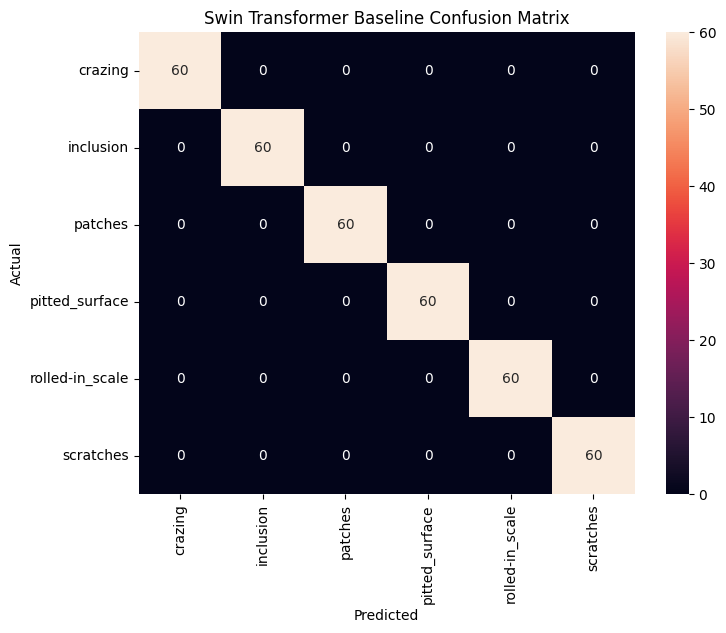

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(
    all_labels,
    all_predictions
)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Swin Transformer Baseline Confusion Matrix")
plt.show()

In [37]:
import torch
torch.save(
    model.state_dict(),
    "/kaggle/working/swin_baseline_neu.pth"
)
print("Baseline model saved successfully")

Baseline model saved successfully


# Confidence Estimation (Baseline Trust Indicator)

Confidence estimation is used as the baseline trust indicator to measure how certain the model is about its predictions. It is calculated using the highest probability from the model's softmax output. A higher confidence score indicates that the model is more certain about its prediction, while a lower confidence score indicates greater uncertainty. Although confidence provides a simple measure of prediction certainty, it does not always reflect the actual correctness of the prediction and is therefore used as a baseline for trust estimation.

In [39]:
import torch.nn.functional as F

In [40]:
def get_predictions_with_confidence(
    model,
    loader,
    device
):
    model.eval()
    all_labels = []
    all_predictions = []
    all_confidences = []
    all_probabilities = []
    with torch.no_grad():
        for images, labels in tqdm(loader):
            images = images.to(device)
            # Model output
            logits = model(images)
            # Convert logits to probabilities
            probabilities = F.softmax(
                logits,
                dim=1
            )
            # Highest probability class
            confidence, predictions = torch.max(
                probabilities,
                dim=1
            )
            all_labels.extend(
                labels.numpy()
            )
            all_predictions.extend(
                predictions.cpu().numpy()
            )
            all_confidences.extend(
                confidence.cpu().numpy()
            )
            all_probabilities.extend(
                probabilities.cpu().numpy()
            )
    return (
        np.array(all_labels),
        np.array(all_predictions),
        np.array(all_confidences),
        np.array(all_probabilities)
    )

In [41]:
labels, predictions, confidences, probabilities = (
    get_predictions_with_confidence(
        model,
        val_loader,
        device
    )
)
print("Confidence extraction completed")

  0%|          | 0/12 [00:00<?, ?it/s]

Confidence extraction completed


In [42]:
print(
    "Average confidence:",
    confidences.mean()
)
print(
    "Minimum confidence:",
    confidences.min()
)
print(
    "Maximum confidence:",
    confidences.max()
)

Average confidence: 0.99994344
Minimum confidence: 0.9824802
Maximum confidence: 1.0


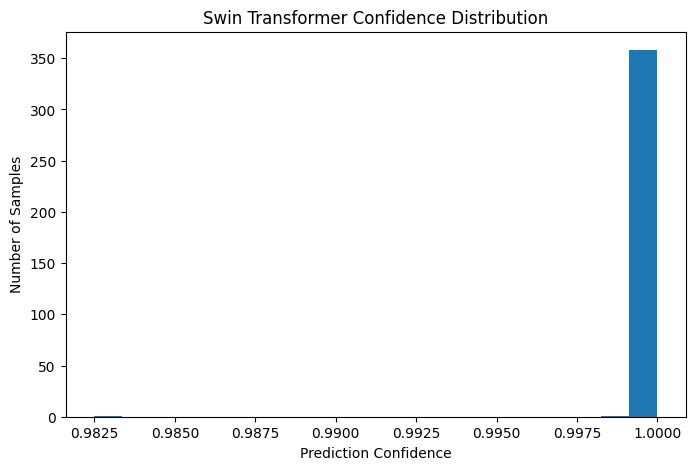

In [43]:
plt.figure(figsize=(8,5))
plt.hist(
    confidences,
    bins=20
)
plt.xlabel(
    "Prediction Confidence"
)
plt.ylabel(
    "Number of Samples"
)
plt.title(
    "Swin Transformer Confidence Distribution"
)
plt.show()

In [44]:
import pandas as pd
confidence_results = pd.DataFrame({
    "true_label": labels,
    "prediction": predictions,
    "confidence": confidences
})
confidence_results.to_csv(
    "/kaggle/working/baseline_confidence_results.csv",
    index=False
)
print("Confidence results saved")

Confidence results saved


# Confidence Calibration

Confidence calibration is the process of adjusting a model's confidence scores so that they better reflect the true likelihood of making correct predictions. A well-calibrated model produces confidence scores that closely match its actual accuracy. For example, if a model assigns a confidence of 90% to a group of predictions, then approximately 90% of those predictions should be correct.

Calibration helps reduce overconfident or underconfident predictions, making the model's outputs more reliable for decision-making. In this work, confidence calibration is used to improve the quality of confidence estimates before they are incorporated into the trust estimation framework.

In [45]:
def get_logits_and_labels(
    model,
    loader,
    device
):
    model.eval()
    logits_list = []
    labels_list = []
    with torch.no_grad():
        for images, labels in tqdm(loader):
            images = images.to(device)
            logits = model(images)
            logits_list.append(
                logits.cpu()
            )
            labels_list.append(
                labels
            )
    logits = torch.cat(
        logits_list
    )
    labels = torch.cat(
        labels_list
    )
    return logits, labels

In [46]:
val_logits, val_labels = get_logits_and_labels(
    model,
    val_loader,
    device
)
print("Logits shape:", val_logits.shape)
print("Labels shape:", val_labels.shape)

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ba045972fc0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
        

  0%|          | 0/12 [00:00<?, ?it/s]

   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process


Logits shape: torch.Size([360, 6])
Labels shape: torch.Size([360])


In [49]:
class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(
            torch.ones(1) * 1.5
        )
    def forward(self, logits):
        temperature = self.temperature
        return logits / temperature

In [50]:
temperature_model = TemperatureScaler()
temperature_model.to(device)
optimizer_temp = torch.optim.LBFGS(
    [temperature_model.temperature],
    lr=0.01,
    max_iter=50
)
criterion_temp = nn.CrossEntropyLoss()
logits = val_logits.to(device)
labels_temp = val_labels.to(device)

In [51]:
def eval_temperature():
    optimizer_temp.zero_grad()
    scaled_logits = temperature_model(
        logits
    )
    loss = criterion_temp(
        scaled_logits,
        labels_temp
    )
    loss.backward()
    return loss
optimizer_temp.step(
    eval_temperature
)
print(
    "Optimal temperature:",
    temperature_model.temperature.item()
)

Optimal temperature: 1.5013915300369263


In [52]:
with torch.no_grad():
    calibrated_logits = temperature_model(
        logits
    )
    calibrated_probs = F.softmax(
        calibrated_logits,
        dim=1
    )
calibrated_confidence, calibrated_predictions = torch.max(
    calibrated_probs,
    dim=1
)
print(
    "Before calibration:",
    confidences.mean()
)
print(
    "After calibration:",
    calibrated_confidence.mean().item()
)

Before calibration: 0.99994344
After calibration: 0.9994433522224426


In [53]:
def expected_calibration_error(
    confidences,
    predictions,
    labels,
    n_bins=10
):
    ece = 0.0
    bin_boundaries = torch.linspace(
        0,
        1,
        n_bins + 1
    )
    for i in range(n_bins):
        lower = bin_boundaries[i]
        upper = bin_boundaries[i+1]
        mask = (
            (confidences > lower)
            &
            (confidences <= upper)
        )
        if mask.sum() > 0:
            bin_confidence = (
                confidences[mask]
                .mean()
            )
            bin_accuracy = (
                predictions[mask]
                ==
                labels[mask]
            ).float().mean()
            ece += (
                mask.float().mean()
                *
                torch.abs(
                    bin_accuracy -
                    bin_confidence
                )
            )
    return ece.item()

In [54]:
before_confidence = torch.tensor(
    confidences
)
before_predictions = torch.tensor(
    predictions
)
true_labels = torch.tensor(
    labels
)
ece_before = expected_calibration_error(
    before_confidence,
    before_predictions,
    true_labels
)
print(
    "ECE Before Calibration:",
    ece_before
)

ECE Before Calibration: 0.0027211904525756836


In [55]:
after_confidence = calibrated_confidence.cpu()
after_predictions = calibrated_predictions.cpu()
ece_after = expected_calibration_error(
    after_confidence,
    after_predictions,
    true_labels
)
print(
    "ECE After Calibration:",
    ece_after
)

ECE After Calibration: 0.002221047878265381


# Uncertainty Estimation

Uncertainty estimation measures how unsure a model is about its predictions. Unlike confidence, which indicates how certain the model appears to be, uncertainty estimation identifies predictions that may be unreliable. Higher uncertainty values indicate that the model is less confident in its prediction, while lower uncertainty values suggest greater reliability. In this work, uncertainty estimation is used alongside confidence calibration to improve the overall trustworthiness of the model's predictions.

In [56]:
def enable_dropout(model):
    for module in model.modules():
        if isinstance(
            module,
            nn.Dropout
        ):
            module.train()
print("Dropout enabling function created")

Dropout enabling function created


In [57]:
def monte_carlo_predictions(
    model,
    images,
    device,
    n_samples=20
):
    model.eval()
    enable_dropout(model)
    predictions = []
    with torch.no_grad():
        for _ in range(n_samples):
            outputs = model(
                images.to(device)
            )
            probabilities = F.softmax(
                outputs,
                dim=1
            )
            predictions.append(
                probabilities.cpu()
            )
    predictions = torch.stack(
        predictions
    )
    return predictions

In [58]:
images, labels = next(
    iter(val_loader)
)
mc_probs = monte_carlo_predictions(
    model,
    images,
    device,
    n_samples=20
)
print(
    "MC prediction shape:",
    mc_probs.shape
)

MC prediction shape: torch.Size([20, 32, 6])


In [59]:
mean_probabilities = mc_probs.mean(
    dim=0
)
print(
    mean_probabilities.shape
)

torch.Size([32, 6])


In [62]:
def predictive_entropy(probabilities):
    entropy = -torch.sum(
        probabilities *
        torch.log(
            probabilities + 1e-8
        ),
        dim=1
    )
    return entropy

In [63]:
uncertainty = predictive_entropy(
    mean_probabilities
)
print(
    "Mean uncertainty:",
    uncertainty.mean().item()
)
print(
    "Maximum uncertainty:",
    uncertainty.max().item()
)

Mean uncertainty: 3.257004209444858e-05
Maximum uncertainty: 6.917119026184082e-05


In [64]:
def evaluate_uncertainty(
    model,
    loader,
    device,
    n_samples=20
):
    all_uncertainties = []
    all_labels = []
    model.eval()
    for images, labels in tqdm(loader):

        mc_probs = monte_carlo_predictions(
            model,
            images,
            device,
            n_samples
        )
        mean_probs = mc_probs.mean(
            dim=0
        )
        entropy = predictive_entropy(
            mean_probs
        )
        all_uncertainties.extend(
            entropy.numpy()
        )
        all_labels.extend(
            labels.numpy()
        )
    return (
        np.array(all_uncertainties),
        np.array(all_labels)
    )

In [65]:
uncertainties, uncertainty_labels = evaluate_uncertainty(
    model,
    val_loader,
    device,
    n_samples=20
)
print("Mean uncertainty:", uncertainties.mean())
print("Maximum uncertainty:", uncertainties.max())

  0%|          | 0/12 [00:00<?, ?it/s]

Mean uncertainty: 0.0003551421
Maximum uncertainty: 0.097515695


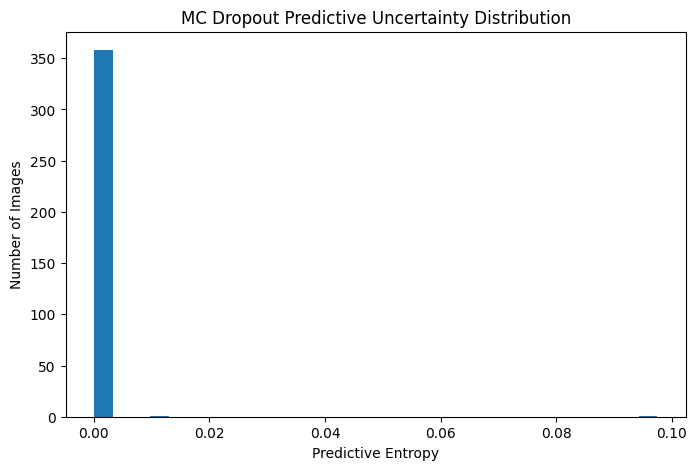

In [66]:
plt.figure(figsize=(8,5))
plt.hist(
    uncertainties,
    bins=30
)
plt.xlabel("Predictive Entropy")
plt.ylabel("Number of Images")
plt.title(
    "MC Dropout Predictive Uncertainty Distribution"
)
plt.show()

In [67]:
import pandas as pd
uncertainty_df = pd.DataFrame({
    "class": [
        train_dataset.classes[i]
        for i in uncertainty_labels
    ],
    "uncertainty": uncertainties
})
class_uncertainty = (
    uncertainty_df
    .groupby("class")
    ["uncertainty"]
    .mean()
)
print(class_uncertainty)

class
crazing            0.000033
inclusion          0.001966
patches            0.000003
pitted_surface     0.000033
rolled-in_scale    0.000025
scratches          0.000071
Name: uncertainty, dtype: float32


# Adaptive Trust-Aware Decision Module

The Adaptive Trust-Aware Decision Module uses the calculated trust score to determine whether a model's prediction should be accepted or rejected. Instead of relying only on the predicted class, it considers the reliability of each prediction based on confidence, calibration, and uncertainty. Predictions with trust scores above a predefined threshold are accepted, while those below the threshold are rejected or flagged for further review. This adaptive approach improves the reliability of the decision-making process by reducing the risk of accepting uncertain or unreliable predictions.

In [73]:
def normalize_uncertainty(uncertainties):
    u_min = uncertainties.min()
    u_max = uncertainties.max()
    normalized = (
        (uncertainties - u_min)
        /
        (u_max - u_min + 1e-8)
    )
    return normalized

In [74]:
normalized_uncertainties = normalize_uncertainty(
    uncertainties
)
print(
    "Min normalized uncertainty:",
    normalized_uncertainties.min()
)
print(
    "Max normalized uncertainty:",
    normalized_uncertainties.max()
)

Min normalized uncertainty: 0.0
Max normalized uncertainty: 0.99999994


In [75]:
def compute_trust_score(
    confidence,
    normalized_uncertainty
):
    trust_score = (
        confidence
        *
        (1 - normalized_uncertainty)
    )
    return trust_score

In [76]:
trust_scores = compute_trust_score(
    calibrated_confidence.cpu().numpy(),
    normalized_uncertainties
)
print(
    "Average Trust Score:",
    trust_scores.mean()
)
print(
    "Minimum Trust Score:",
    trust_scores.min()
)
print(
    "Maximum Trust Score:",
    trust_scores.max()
)

Average Trust Score: 0.9960355
Minimum Trust Score: 5.4785826e-08
Maximum Trust Score: 0.9999865


In [77]:
def trust_decision(
    trust_score,
    high_threshold=0.90,
    low_threshold=0.60
):
    decisions = []
    for score in trust_score:
        if score >= high_threshold:
            decisions.append(
                "Accept"
            )
        elif score >= low_threshold:
            decisions.append(
                "Human Review"
            )
        else:
            decisions.append(
                "Reject"
            )
    return decisions

In [78]:
decisions = trust_decision(
    trust_scores
)
from collections import Counter
print(
    Counter(decisions)
)

Counter({'Accept': 358, 'Human Review': 1, 'Reject': 1})


In [79]:
accepted_count = decisions.count(
    "Accept"
)
total_count = len(
    decisions
)
coverage = (
    accepted_count /
    total_count
)
print(
    "Coverage:",
    coverage
)
print(
    "Coverage percentage:",
    coverage * 100,
    "%"
)

Coverage: 0.9944444444444445
Coverage percentage: 99.44444444444444 %


In [80]:
reject_count = decisions.count(
    "Reject"
)
review_count = decisions.count(
    "Human Review"
)
rejection_rate = (
    (reject_count + review_count)
    /
    total_count
)
print(
    "Reject count:",
    reject_count
)
print(
    "Human Review count:",
    review_count
)
print(
    "Rejection/Review Rate:",
    rejection_rate * 100,
    "%"
)

Reject count: 1
Human Review count: 1
Rejection/Review Rate: 0.5555555555555556 %


In [81]:
# Extract full validation predictions again
full_labels, full_predictions, full_confidences, full_probabilities = (
    get_predictions_with_confidence(
        model,
        val_loader,
        device
    )
)
print("Labels:", len(full_labels))
print("Predictions:", len(full_predictions))
print("Decisions:", len(decisions))

  0%|          | 0/12 [00:00<?, ?it/s]

Labels: 360
Predictions: 360
Decisions: 360


In [82]:
accepted_indices = [
    i for i, d in enumerate(decisions)
    if d == "Accept"
]
accepted_predictions = full_predictions[
    accepted_indices
]
accepted_labels = full_labels[
    accepted_indices
]
selective_accuracy = (
    accepted_predictions ==
    accepted_labels
).mean()
print(
    "Selective Accuracy:",
    selective_accuracy * 100,
    "%"
)

Selective Accuracy: 100.0 %


In [83]:
def evaluate_threshold(
    trust_scores,
    predictions,
    labels,
    threshold
):
    decisions = []
    for score in trust_scores:
        if score >= threshold:
            decisions.append("Accept")
        else:
            decisions.append("Review")
    accepted_indices = [
        i for i, d in enumerate(decisions)
        if d == "Accept"
    ]
    accepted_count = len(
        accepted_indices
    )
    total = len(
        labels
    )
    # Coverage
    coverage = (
        accepted_count /
        total
    )
    # Selective accuracy
    if accepted_count > 0:
        accepted_predictions = predictions[
            accepted_indices
        ]
        accepted_labels = labels[
            accepted_indices
        ]
        selective_accuracy = (
            accepted_predictions ==
            accepted_labels
        ).mean()
    else:
        selective_accuracy = 0
    return {
        "threshold": threshold,
        "accepted": accepted_count,
        "review": total - accepted_count,
        "coverage": coverage,
        "selective_accuracy": selective_accuracy
    }

In [84]:
thresholds = [
    0.95,
    0.90,
    0.85,
    0.80,
    0.75
]
threshold_results = []
for t in thresholds:
    result = evaluate_threshold(
        trust_scores,
        full_predictions,
        full_labels,
        t
    )
    threshold_results.append(
        result
    )
threshold_df = pd.DataFrame(
    threshold_results
)
threshold_df

,threshold,accepted,review,coverage,selective_accuracy
0,0.95,358,2,0.994444,1.0
1,0.90,358,2,0.994444,1.0
2,0.85,359,1,0.997222,1.0
3,0.80,359,1,0.997222,1.0
4,0.75,359,1,0.997222,1.0


In [87]:
trust_results = pd.DataFrame({
    "true_label": full_labels,
    "prediction": full_predictions,
    "confidence": calibrated_confidence.cpu().numpy(),
    "uncertainty": uncertainties,
    "trust_score": trust_scores,
    "decision": decisions
})
print(
    trust_results.head()
)
print(
    trust_results.shape
)

   true_label  prediction  confidence  uncertainty  trust_score decision
0           0           0    0.999740     0.000032     0.999411   Accept
1           0           0    0.999744     0.000031     0.999427   Accept
2           0           0    0.999780     0.000025     0.999524   Accept
3           0           0    0.999774     0.000026     0.999509   Accept
4           0           0    0.999719     0.000036     0.999355   Accept
(360, 6)


In [88]:
threshold_df.to_csv(
    "/kaggle/working/threshold_analysis.csv",
    index=False
)
trust_results.to_csv(
    "/kaggle/working/trust_results.csv",
    index=False
)
print(
    "Trust experiment results saved successfully"
)

Trust experiment results saved successfully


# Ablation Studies

## Confidence Only Baseline

The Confidence Only Baseline evaluates the model using only the confidence score as the trust indicator. Predictions are accepted or rejected based solely on their confidence values without considering confidence calibration or uncertainty estimation. This baseline serves as a reference to compare the effectiveness of the proposed trust-aware framework. By comparing its performance with the complete framework, the contribution of calibration and uncertainty estimation to improving prediction reliability can be clearly demonstrated.

In [89]:
def confidence_only_decision(
    confidence,
    threshold=0.90
):
    decisions=[]
    for c in confidence:
        if c >= threshold:
            decisions.append("Accept")
        else:
            decisions.append("Reject")
    return decisions

In [90]:
confidence_decisions = confidence_only_decision(
    calibrated_confidence.cpu().numpy(),
    threshold=0.90
)
from collections import Counter
print(
    Counter(confidence_decisions)
)

Counter({'Accept': 360})


In [91]:
confidence_accept = confidence_decisions.count(
    "Accept"
)
confidence_coverage = (
    confidence_accept /
    len(confidence_decisions)
)
print(
    "Confidence-only coverage:",
    confidence_coverage*100,
    "%"
)

Confidence-only coverage: 100.0 %


## Confidence + Calibration

The Confidence + Calibration baseline evaluates the model using both the confidence score and calibrated confidence as trust indicators. Confidence calibration adjusts the model's confidence scores to better match the true likelihood of correct predictions, making them more reliable. However, this baseline does not include uncertainty estimation. Comparing this approach with the proposed framework helps demonstrate the additional benefit of incorporating uncertainty estimation into trust-aware decision-making.

In [95]:
calibrated_confidence_decisions = confidence_only_decision(
    calibrated_confidence.cpu().numpy(),
    threshold=0.90
)
from collections import Counter
print(
    Counter(calibrated_confidence_decisions)
)

Counter({'Accept': 360})


In [96]:
calibrated_accept = calibrated_confidence_decisions.count(
    "Accept"
)
calibrated_coverage = (
    calibrated_accept /
    len(calibrated_confidence_decisions)
)
print(
    "Calibration-only coverage:",
    calibrated_coverage*100,
    "%"
)

Calibration-only coverage: 100.0 %


## Confidence + Calibration + Uncertainty

The Confidence + Calibration + Uncertainty approach represents the complete proposed trust-aware framework. It combines the model's confidence score, calibrated confidence, and uncertainty estimation to compute a comprehensive trust score for each prediction. This combined approach provides a more reliable assessment of prediction quality, allowing the system to make better accept-or-reject decisions. Comparing this approach with the baseline methods demonstrates the effectiveness of integrating calibration and uncertainty estimation to improve trustworthiness.

In [97]:
a4_decisions = trust_decision(
    trust_scores,
    high_threshold=0.90,
    low_threshold=0.60
)
from collections import Counter
print(
    Counter(a4_decisions)
)

Counter({'Accept': 358, 'Human Review': 1, 'Reject': 1})


In [98]:
a4_accept = a4_decisions.count(
    "Accept"
)
a4_coverage = (
    a4_accept /
    len(a4_decisions)
)
print(
    "A4 Coverage:",
    a4_coverage*100,
    "%"
)

A4 Coverage: 99.44444444444444 %


# Define OOD Transformations

Out-of-Distribution (OOD) transformations are applied to test data to simulate conditions that differ from the data used during model training. These transformations create inputs that are more challenging for the model, helping evaluate its robustness and ability to recognize unfamiliar or degraded samples. Common OOD transformations include image corruption, noise, blur, brightness changes, rotation, scaling, and occlusion. In this work, OOD transformations are used to assess the reliability and trustworthiness of the proposed trust-aware framework under distribution shifts.

In [99]:
from torchvision import transforms
from PIL import ImageFilter
# OOD transformation pipeline
ood_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda img: img.filter(ImageFilter.GaussianBlur(radius=2))),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [100]:
from torchvision.datasets import ImageFolder
ood_dataset = ImageFolder(
    root=VAL_DIR,
    transform=ood_transform
)
ood_loader = DataLoader(
    ood_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)
print("OOD Images:", len(ood_dataset))

OOD Images: 360


In [101]:
ood_labels, ood_predictions, ood_confidence, ood_probabilities = (
    get_predictions_with_confidence(
        model,
        ood_loader,
        device
    )
)
print("OOD samples:", len(ood_labels))

  0%|          | 0/12 [00:00<?, ?it/s]

OOD samples: 360


In [102]:
print("========== Confidence Comparison ==========")
print("ID Mean Confidence:",
      calibrated_confidence.mean().item())
print("OOD Mean Confidence:",
      ood_confidence.mean())

========== Confidence Comparison ==========
ID Mean Confidence: 0.9994433522224426
OOD Mean Confidence: 0.97929096


In [106]:
import numpy as np
import torch
import torch.nn.functional as F
def compute_dataset_uncertainty(
    model,
    dataloader,
    device,
    mc_samples=20
):
    """
    Compute predictive uncertainty using Monte Carlo Dropout.
    Returns:
        uncertainties (numpy array)
        predictions (numpy array)
    """
    model.train()   # Enable dropout
    uncertainties = []
    predictions = []
    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(device)
            mc_outputs = []
            for _ in range(mc_samples):
                logits = model(images)
                probs = F.softmax(logits, dim=1)
                mc_outputs.append(probs.unsqueeze(0))
            mc_outputs = torch.cat(mc_outputs, dim=0)
            mean_probs = mc_outputs.mean(dim=0)
            entropy = -torch.sum(
                mean_probs * torch.log(mean_probs + 1e-12),
                dim=1
            )
            pred = mean_probs.argmax(dim=1)
            uncertainties.extend(
                entropy.cpu().numpy()
            )
            predictions.extend(
                pred.cpu().numpy()
            )
    model.eval()
    return np.array(uncertainties), np.array(predictions)

In [107]:
ood_uncertainties, _ = compute_dataset_uncertainty(
    model,
    ood_loader,
    device,
    mc_samples=20
)
print("Mean OOD uncertainty:",
      ood_uncertainties.mean())
print("Maximum OOD uncertainty:",
      ood_uncertainties.max())

Mean OOD uncertainty: 0.13365936
Maximum OOD uncertainty: 0.9385755


In [108]:
ood_normalized_uncertainty = normalize_uncertainty(
    ood_uncertainties
)

In [109]:
ood_trust_scores = compute_trust_score(
    ood_confidence,
    ood_normalized_uncertainty
)
print("Mean OOD Trust Score:",
      ood_trust_scores.mean())

Mean OOD Trust Score: 0.85294646


In [110]:
print("========== Comparison ==========")
print("ID Mean Trust Score :",
      trust_scores.mean())
print("OOD Mean Trust Score:",
      ood_trust_scores.mean())
print("ID Mean Uncertainty :",
      uncertainties.mean())
print("OOD Mean Uncertainty:",
      ood_uncertainties.mean())

========== Comparison ==========
ID Mean Trust Score : 0.9960355
OOD Mean Trust Score: 0.85294646
ID Mean Uncertainty : 0.0003551421
OOD Mean Uncertainty: 0.13365936


In [111]:
ood_decisions = trust_decision(
    ood_trust_scores,
    high_threshold=0.90,
    low_threshold=0.60
)
from collections import Counter
print(Counter(ood_decisions))

Counter({'Accept': 264, 'Reject': 60, 'Human Review': 36})


In [112]:
ood_accept = ood_decisions.count("Accept")
ood_review = ood_decisions.count("Human Review")
ood_reject = ood_decisions.count("Reject")
total = len(ood_decisions)
print(f"Accept       : {ood_accept}")
print(f"Human Review : {ood_review}")
print(f"Reject       : {ood_reject}")
print(f"Coverage     : {100 * ood_accept / total:.2f}%")

Accept       : 264
Human Review : 36
Reject       : 60
Coverage     : 73.33%
